In [1]:
RUN_TARGET = "local"  # "colab" | "local"


## Setup Instructions

### Running on Google Colab
1. Set `RUN_TARGET = "colab"` in Cell 1.
2. Run the install cell and restart if requested.
3. Mount Drive if you want to read synced `models/` and `results/` artifacts.
4. Run the remaining cells top to bottom.

### Running locally
1. Keep `RUN_TARGET = "local"`.
2. The notebook scans the local `models/` and `results/` folders.
3. It overlays all available probe artifacts on shared comparison plots.


In [2]:
if RUN_TARGET == "colab":
    import importlib.metadata as _md
    import subprocess as _sp
    import sys as _sys

    _required = {
        "numpy": "1.26.4",
        "scipy": "1.15.3",
        "scikit-learn": "1.8.0",
        "transformers": "4.48.1",
        "huggingface-hub": "0.36.2",
        "statsmodels": "0.14.5",
        "seaborn": "0.13.2",
    }

    def _version_matches(name: str, expected: str) -> bool:
        try:
            return _md.version(name) == expected
        except _md.PackageNotFoundError:
            return False

    _missing_or_mismatched = [
        f"{name}=={version}"
        for name, version in _required.items()
        if not _version_matches(name, version)
    ]

    if _missing_or_mismatched:
        print("Installing:", ", ".join(_missing_or_mismatched))
        _sp.run([
            _sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            *_missing_or_mismatched,
        ], check=True)
        raise SystemExit(
            "Colab environment updated. Restart the runtime once, then rerun the notebook from the top."
        )
    else:
        print("Colab environment already compatible. No reinstall needed.")
else:
    print("Local environment detected. Skipping Colab setup.")


Local environment detected. Skipping Colab setup.


In [3]:
if RUN_TARGET == "colab":
    from google.colab import drive as _drive
    from pathlib import Path

    _drive.mount("/content/drive", force_remount=False)
    DRIVE_ROOT = Path("/content/drive/MyDrive/XAllergen2.0")
    DRIVE_MODELS = DRIVE_ROOT / "models"
    DRIVE_RESULTS = DRIVE_ROOT / "results"
    print(f"Google Drive mounted: {DRIVE_ROOT}")
else:
    print("Local run: skipping Google Drive mount.")


Local run: skipping Google Drive mount.


# 08 - Cross-Model Probe Visualisation

This notebook is the centralized visualization layer for probe outputs that already exist in `results/`. It does not generate IG or attention scores itself; it only discovers saved probe-row CSVs and plots them together for comparison.


In [4]:
import sys
from pathlib import Path
import importlib

if RUN_TARGET == "colab":
    RUNTIME_ROOT = Path("/content/XAllergen2.0")
    if str(RUNTIME_ROOT) not in sys.path:
        sys.path.insert(0, str(RUNTIME_ROOT))

import baseline_notebook_utils
import mtl_epitope_notebook_utils

importlib.reload(baseline_notebook_utils)
importlib.reload(mtl_epitope_notebook_utils)

from baseline_notebook_utils import configure_matplotlib_cache, detect_device, find_project_root, print_runtime_context
from mtl_epitope_notebook_utils import plot_probe_binned_density_trends, plot_probe_density_trends, plot_probe_paired_deltas, plot_probe_violins

if RUN_TARGET != "colab":
    configure_matplotlib_cache(Path.cwd())

import pandas as pd


/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
if RUN_TARGET == "colab":
    PROJECT_ROOT = RUNTIME_ROOT
    MODELS_DIR = DRIVE_MODELS if DRIVE_MODELS.exists() else PROJECT_ROOT / "models"
    RESULTS_DIR = DRIVE_RESULTS if DRIVE_RESULTS.exists() else PROJECT_ROOT / "results"
    print(f"Using models dir: {MODELS_DIR}")
    print(f"Using results dir: {RESULTS_DIR}")
else:
    PROJECT_ROOT = find_project_root(Path.cwd())
    DEVICE = detect_device()
    print_runtime_context(DEVICE, PROJECT_ROOT)
    MODELS_DIR = PROJECT_ROOT / "models"
    RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)


RUN_TARGET: local
Device: mps
Project root: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0
GPU configuration:
  backend: Apple Metal Performance Shaders (MPS)
  built with MPS: True
  MPS available: True


## Discover Available Variants

Each compatible checkpoint in `models/` is mapped to the probe-row CSV that should already exist in `results/`. If a probe artifact is missing, this notebook skips that model rather than recomputing it. Use `07_generate_probe_rows.ipynb` to generate or refresh missing probe artifacts first.


In [6]:
def infer_variant_from_checkpoint_name(checkpoint_name: str) -> tuple[str | None, str | None]:
    if checkpoint_name == "baseline_frozen_esm2.pt":
        return "baseline", "Baseline (04)"
    if checkpoint_name == "mtl_frozen_esm2_epitope.pt":
        return "frozen", "MTL (05 frozen)"
    if checkpoint_name.startswith("mtl_") and checkpoint_name.endswith("_esm2_epitope.pt"):
        variant = checkpoint_name[len("mtl_") : -len("_esm2_epitope.pt")]
        if variant:
            return variant, f"MTL ({variant})"
    return None, None


def probe_rows_path_for_variant(variant: str) -> Path:
    if variant == "baseline":
        return RESULTS_DIR / "baseline_probing_rows.csv"
    if variant == "frozen":
        return RESULTS_DIR / "mtl_probing_rows.csv"
    return RESULTS_DIR / f"mtl_{variant}_probing_rows.csv"


records = []
for checkpoint_path in sorted(MODELS_DIR.glob("*.pt")):
    variant, default_label = infer_variant_from_checkpoint_name(checkpoint_path.name)
    if variant is None:
        continue
    probe_rows_path = probe_rows_path_for_variant(variant)
    records.append(
        {
            "checkpoint_name": checkpoint_path.name,
            "variant": variant,
            "model_family": default_label,
            "checkpoint_path": checkpoint_path,
            "probe_rows_path": probe_rows_path,
            "probe_rows_exists": probe_rows_path.exists(),
        }
    )

discovery_df = pd.DataFrame(records)
discovery_df


,checkpoint_name,variant,model_family,checkpoint_path,probe_rows_path,probe_rows_exists
0,baseline_frozen_esm2.pt,baseline,Baseline (04),/Users/jianzhouyao/Library/Mobile Documents/co...,/Users/jianzhouyao/Library/Mobile Documents/co...,True
1,mtl_frozen_esm2_epitope.pt,frozen,MTL (05 frozen),/Users/jianzhouyao/Library/Mobile Documents/co...,/Users/jianzhouyao/Library/Mobile Documents/co...,True
2,mtl_top1_unfrozen_esm2_epitope.pt,top1_unfrozen,MTL (top1_unfrozen),/Users/jianzhouyao/Library/Mobile Documents/co...,/Users/jianzhouyao/Library/Mobile Documents/co...,True


In [7]:
available_df = discovery_df[discovery_df["probe_rows_exists"]].copy()
if available_df.empty:
    raise FileNotFoundError(
        f"No matching probe-row CSVs were found in {RESULTS_DIR}. Run notebook 04, 05, or 06 first."
    )

family_label_overrides = {
    "baseline": "Baseline (04)",
    "frozen": "MTL (05 frozen)",
    "top1_unfrozen": "MTL (06 top1_unfrozen)",
}

frames = []
for row in available_df.itertuples(index=False):
    frame = pd.read_csv(row.probe_rows_path)
    family_label = family_label_overrides.get(row.variant, row.model_family)
    frame = frame.copy()
    frame["model_family"] = family_label
    frame["source_probe_rows_path"] = str(row.probe_rows_path)
    frames.append(frame)

all_probe_df = pd.concat(frames, ignore_index=True)
all_probe_df.head()


,accession,seq_len,epitope_density,n_epitope_residues,method,auroc,auprc,precision_at_k,ig_scores_json,model_family,source_probe_rows_path
0,A0A834K244,251,0.549801,138,attention_weights,0.630242,0.621814,0.623188,NaN,Baseline (04),/Users/jianzhouyao/Library/Mobile Documents/co...
1,A0A834K244,251,0.549801,138,integrated_gradients,0.474349,0.535056,0.492754,"[4.455720901489258,2.856628894805908,1.4541363...",Baseline (04),/Users/jianzhouyao/Library/Mobile Documents/co...
2,A0A834K244,251,0.549801,138,random_mean,0.496637,0.555965,0.547971,NaN,Baseline (04),/Users/jianzhouyao/Library/Mobile Documents/co...
3,A0A834K244,251,0.549801,138,shuffled_mean,0.506285,0.563736,0.554638,NaN,Baseline (04),/Users/jianzhouyao/Library/Mobile Documents/co...
4,P49372,154,0.642857,99,attention_weights,0.250321,0.499444,0.525253,NaN,Baseline (04),/Users/jianzhouyao/Library/Mobile Documents/co...


## Save Combined Tables

These artifacts provide a single row-wise table plus a compact mean and standard-deviation summary across all available families.

In [8]:
MULTI_MODEL_ROWS_CSV = RESULTS_DIR / "all_models_probing_rows.csv"
MULTI_MODEL_SUMMARY_CSV = RESULTS_DIR / "all_models_probing_summary.csv"
MULTI_MODEL_VIOLINS_PNG = RESULTS_DIR / "all_models_probing_violins.png"
MULTI_MODEL_AUROC_PNG = RESULTS_DIR / "all_models_probing_auroc_vs_density.png"
MULTI_MODEL_AUPRC_PNG = RESULTS_DIR / "all_models_probing_auprc_vs_density.png"

all_probe_df.to_csv(MULTI_MODEL_ROWS_CSV, index=False)
summary_df = (
    all_probe_df.groupby(["model_family", "method"], as_index=False)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_sd=("auroc", "std"),
        auprc_mean=("auprc", "mean"),
        auprc_sd=("auprc", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_sd=("precision_at_k", "std"),
        n_proteins=("accession", "count"),
    )
)
summary_df = summary_df.round({
    "auroc_mean": 4,
    "auroc_sd": 4,
    "auprc_mean": 4,
    "auprc_sd": 4,
    "precision_at_k_mean": 4,
    "precision_at_k_sd": 4,
})
summary_df.to_csv(MULTI_MODEL_SUMMARY_CSV, index=False)
summary_df


,model_family,method,auroc_mean,auroc_sd,auprc_mean,auprc_sd,precision_at_k_mean,precision_at_k_sd,n_proteins
0,Baseline (04),attention_weights,0.4438,0.1202,0.2468,0.1997,0.2131,0.2136,58
1,Baseline (04),integrated_gradients,0.4328,0.1606,0.2550,0.2067,0.2189,0.2244,58
2,Baseline (04),random_mean,0.4985,0.0064,0.2683,0.1983,0.2494,0.2005,58
3,Baseline (04),shuffled_mean,0.4983,0.0063,0.2685,0.1981,0.2508,0.2000,58
4,MTL (05 frozen),attention_weights,0.4478,0.1117,0.2462,0.1987,0.2126,0.2128,58
5,MTL (05 frozen),integrated_gradients,0.4434,0.1628,0.2583,0.2100,0.2218,0.2254,58
6,MTL (05 frozen),occlusion,0.4943,0.0742,0.2691,0.1975,0.2398,0.2022,58
7,MTL (05 frozen),random_mean,0.4997,0.0049,0.2692,0.1982,0.2512,0.1998,58
8,MTL (05 frozen),residue_head,0.6495,0.1627,0.3735,0.2575,0.3378,0.2573,58
9,MTL (06 top1_unfrozen),attention_weights,0.4477,0.1141,0.2467,0.1991,0.2140,0.2142,58


## Plot All Available Families

/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/mtl_epitope_notebook_utils.py:1560: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_XLABELS[m] for m in violin_order], fontsize=9)
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/mtl_epitope_notebook_utils.py:1560: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_XLABELS[m] for m in violin_order], fontsize=9)
/Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/mtl_epitope_notebook_utils.py:1560: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([METHOD_XLA

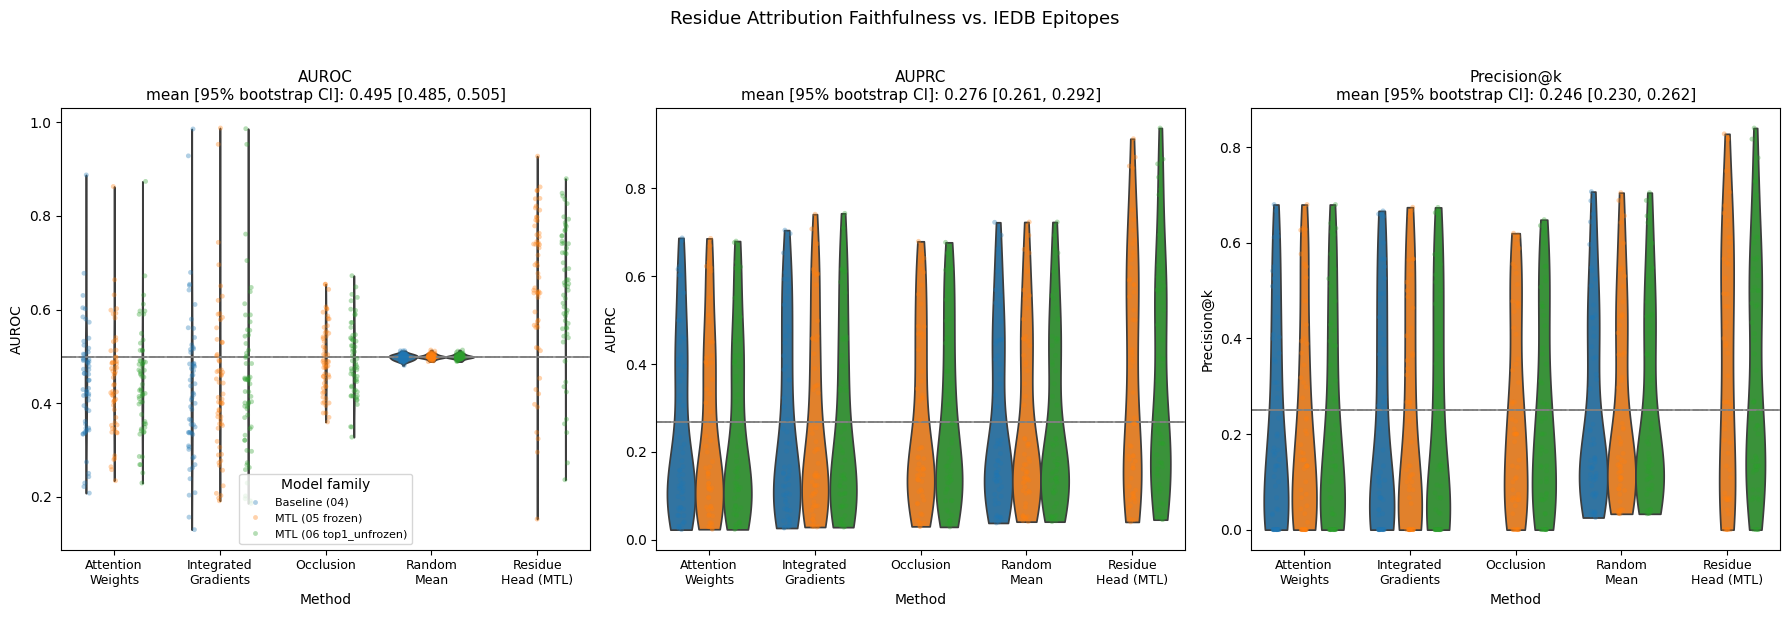

Saved plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/all_models_probing_violins.png


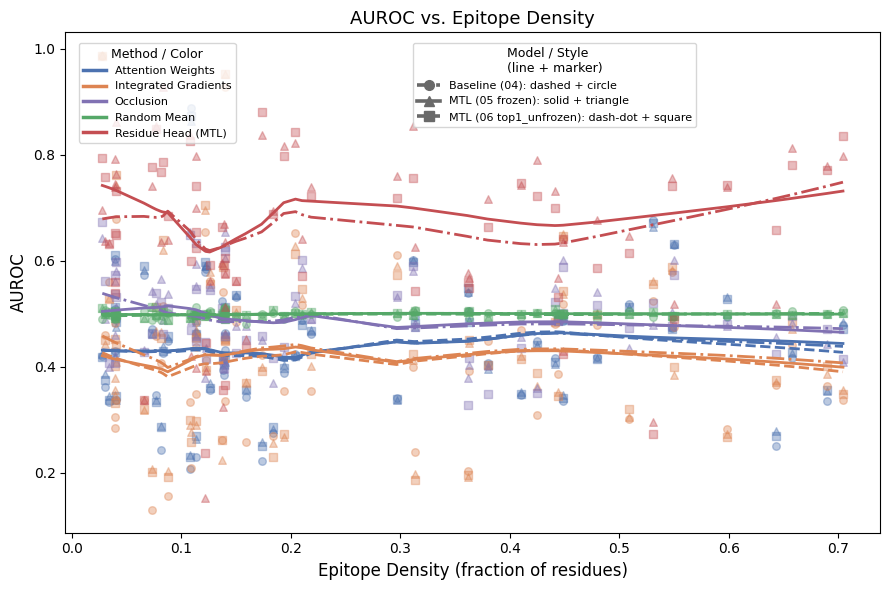

Saved plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/all_models_probing_auroc_vs_density.png


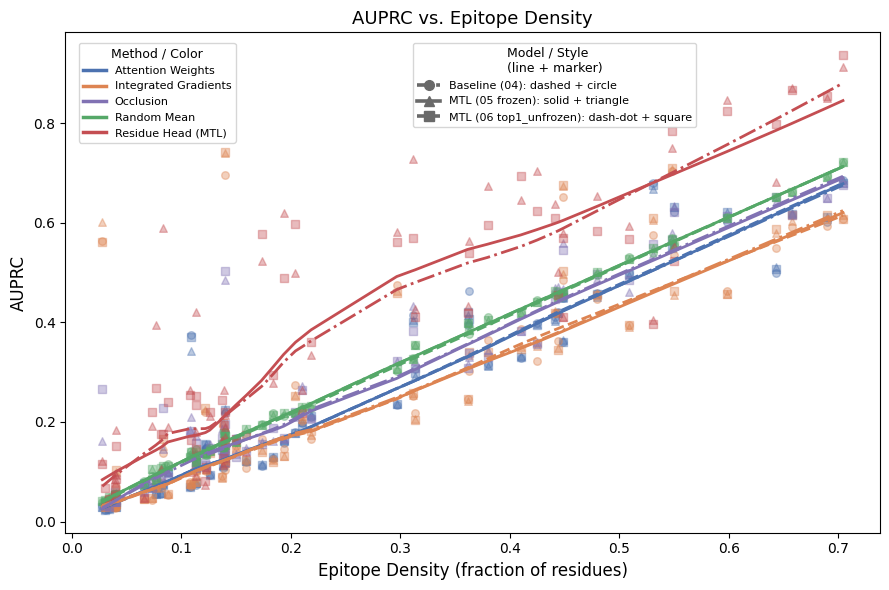

Saved plot to: /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/all_models_probing_auprc_vs_density.png


In [9]:
plot_probe_violins(all_probe_df, MULTI_MODEL_VIOLINS_PNG)
plot_probe_density_trends(
    all_probe_df,
    MULTI_MODEL_AUROC_PNG,
    MULTI_MODEL_AUPRC_PNG,
)


In [10]:
print("Saved combined artifacts:")
for out_path in [
    MULTI_MODEL_ROWS_CSV,
    MULTI_MODEL_SUMMARY_CSV,
    MULTI_MODEL_VIOLINS_PNG,
    MULTI_MODEL_AUROC_PNG,
    MULTI_MODEL_AUPRC_PNG,
]:
    print(f"  {out_path}")


Saved combined artifacts:
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/all_models_probing_rows.csv
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/all_models_probing_summary.csv
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/all_models_probing_violins.png
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/all_models_probing_auroc_vs_density.png
  /Users/jianzhouyao/Library/Mobile Documents/com~apple~CloudDocs/Universität/ETH/DL in Biology/XAllergen2.0/results/all_models_probing_auprc_vs_density.png
